In [1]:
# import libraires
import pandas as pd 
import numpy as np 

In [5]:
np.random.seed(23) 

mu_vec1 = np.array([0,0,0])
cov_mat1 = np.array([[1,0,0],[0,1,0],[0,0,1]])
class1_sample = np.random.multivariate_normal(mu_vec1, cov_mat1, 20)

df = pd.DataFrame(class1_sample,columns=['feature1','feature2','feature3'])
df['target'] = 1

mu_vec2 = np.array([1,1,1])
cov_mat2 = np.array([[1,0,0],[0,1,0],[0,0,1]])
class2_sample = np.random.multivariate_normal(mu_vec2, cov_mat2, 20)

df1 = pd.DataFrame(class2_sample,columns=['feature1','feature2','feature3'])

df1['target'] = 0

df = df = pd.concat([df, df1], ignore_index=True)

df = df.sample(40)

# geting a dataframe from the campus x code 

In [6]:
df.head()

,feature1,feature2,feature3,target
2,-0.367548,-1.137460,-1.322148,1
34,0.177061,-0.598109,1.226512,0
14,0.420623,0.411620,-0.071324,1
11,1.968435,-0.547788,-0.679418,1
12,-2.506230,0.146960,0.606195,1


In [9]:
# Mean centering 
from sklearn.preprocessing import StandardScaler
df.iloc[:,:3] = StandardScaler().fit_transform(df.iloc[:,:3])

In [10]:
df.head()

,feature1,feature2,feature3,target
2,-0.700809,-1.525586,-1.749156,1
34,-0.224481,-1.010757,0.491251,0
14,-0.011456,-0.046935,-0.649616,1
11,1.342296,-0.962723,-1.184163,1
12,-2.571350,-0.299561,-0.054040,1


In [32]:
# Find Covarience Matrix 
covarience = np.cov([df.iloc[:,0],df.iloc[:,1],df.iloc[:,2]])

In [16]:
# Eigen Vectors and Eigen Values
evalue , evector = np.linalg.eig(covarience)

In [17]:
evalue

array([1.3536065 , 0.94557084, 0.77774573])

In [18]:
evector

array([[-0.53875915, -0.69363291,  0.47813384],
       [-0.65608325, -0.01057596, -0.75461442],
       [-0.52848211,  0.72025103,  0.44938304]])

In [19]:
# we got the eigen vectors and values 
pc = evector[0:2]

In [20]:
pc

array([[-0.53875915, -0.69363291,  0.47813384],
       [-0.65608325, -0.01057596, -0.75461442]])

In [21]:
# now transforming our data 
transformed = np.dot(df.iloc[:,:3],pc.T)
new_df = pd.DataFrame(transformed,columns=['PC1','PC2'])

In [26]:
new_df['Target'] = df['target'].values

In [27]:
new_df.head()

,PC1,PC2,Target
0,0.599433,1.795862,1
1,1.056919,-0.212737,0
2,-0.271876,0.498222,1
3,-0.621586,0.023110,1
4,1.567286,1.730967,1


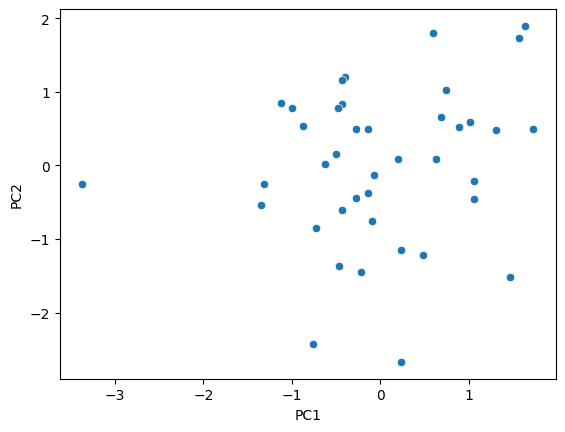

In [29]:
# now we can plot our data in 2d 
import seaborn as sns 
import matplotlib.pyplot as plt
sns.scatterplot(data=new_df,x='PC1',y='PC2')
plt.show()

In [ ]:
# this was the basic intution of PCA next we will learn about scikit learn library for pca